In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

In [4]:
sns.set(style="whitegrid")
sns.set_theme(palette='viridis')

# Load the preprocessed data
data_train = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_train.csv')
data_test = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
data_train['titleType'] = data_train['titleType'].fillna(8.0)
data_test['titleType'] = data_test['titleType'].fillna(8.0)

data_train.info()
data_train.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13943 entries, 0 to 13942
Columns: 205 entries, originalTitle to ZW
dtypes: float64(8), int64(196), object(1)
memory usage: 21.8+ MB


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,0.500000,6.659294,3.091042,0.693147,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Idealnaya para,6,1992,1.500000,3.663562,3.218876,0.000000,1,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
2,MasterChef Celebrity México,6,2021,0.500000,2.772589,4.043051,0.000000,0,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,Lightdance,9,1995,0.566667,2.708050,0.000000,0.000000,7,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
4,"Kiss, Kiss Bang, Bang",8,1995,0.750000,4.574711,4.709530,0.000000,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
5,Estrela de Oito Pontas,8,1996,0.200000,2.564949,1.098612,0.000000,8,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
6,JJBA Mangabridged: Phantom Blood 2 of 2,9,2017,0.733333,3.526361,1.791759,0.000000,3,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,Golubaya chashka,7,1965,1.000000,3.218876,3.610918,0.000000,1,1.386294,0.000000,...,0,0,0,0,0,0,0,0,0,0
8,The Formula,3,2014,1.500000,6.637258,4.955827,0.693147,1,1.791759,1.609438,...,0,0,0,0,0,0,0,0,0,0
9,Kako ubiv svetec,7,2004,1.366667,5.777652,4.442651,0.693147,1,1.945910,1.098612,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Let's add the averageRating column from the csv

df_ratings_train = pd.read_csv('imdb_rating/train_reg.csv')
df_ratings_test = pd.read_csv('imdb_rating/test_reg.csv')

# Creiamo una lista dei 'originalTitle' nel dataset iniziale
titles_in_initial_train = data_train['originalTitle'].tolist()
titles_in_initial_test = data_test['originalTitle'].tolist()

# Filtra il dataframe dei ratings per mantenere solo i titoli che sono presenti anche nel dataset iniziale
df_ratings_filtered_train = df_ratings_train[df_ratings_train['originalTitle'].isin(titles_in_initial_train)]
df_ratings_filtered_test = df_ratings_test[df_ratings_test['originalTitle'].isin(titles_in_initial_test)]

# Unisci i due dataset basandoti sulla colonna 'originalTitle'
data_train = data_train.merge(df_ratings_filtered_train[['originalTitle', 'averageRating']], on='originalTitle', how='left')
data_test = data_test.merge(df_ratings_filtered_test[['originalTitle', 'averageRating']], on='originalTitle', how='left')

# Verifica il risultato
print(data_train.head())


                             originalTitle  rating  startYear  runtimeMinutes  \
0  Neogenic Nightmare Chapter 3: Hydro-Man       8       1995        0.500000   
1                           Idealnaya para       6       1992        1.500000   
2              MasterChef Celebrity México       6       2021        0.500000   
3                               Lightdance       9       1995        0.566667   
4                    Kiss, Kiss Bang, Bang       8       1995        0.750000   

   numVotes  totalCredits  criticReviewsTotal  titleType  numRegions  \
0  6.659294      3.091042            0.693147          2    0.693147   
1  3.663562      3.218876            0.000000          1    0.693147   
2  2.772589      4.043051            0.000000          0    0.693147   
3  2.708050      0.000000            0.000000          7    0.693147   
4  4.574711      4.709530            0.000000          2    0.693147   

   userReviewsTotal  ...  VE  VN  XKV  XWG  XYU  YUCS  ZA  ZM  ZW  \
0          

In [7]:
# Let's use only continuous variables

continuous_columns = [
    'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 
    'averageRating', 'numRegions', 'userReviewsTotal', 'totalRecognitions', 
    'NumberOfCountryoforigin', 'NumberOfGenres', 'totalMedia'
]

train_continuous = data_train[continuous_columns]
test_continuous = data_test[continuous_columns]

# Visualizza il DataFrame con le colonne selezionate
print(train_continuous.head())


   runtimeMinutes  numVotes  totalCredits  criticReviewsTotal  averageRating  \
0        0.500000  6.659294      3.091042            0.693147            7.5   
1        1.500000  3.663562      3.218876            0.000000            5.7   
2        0.500000  2.772589      4.043051            0.000000            5.7   
3        0.566667  2.708050      0.000000            0.000000            8.6   
4        0.750000  4.574711      4.709530            0.000000            7.9   

   numRegions  userReviewsTotal  totalRecognitions  NumberOfCountryoforigin  \
0    0.693147          0.000000                0.0                        1   
1    0.693147          0.693147                0.0                        1   
2    0.693147          0.000000                0.0                        1   
3    0.693147          0.693147                0.0                        1   
4    0.693147          0.000000                0.0                        1   

   NumberOfGenres  totalMedia  
0           

In [8]:
# Compute the Spearman correlation matrix
corr, _ = spearmanr(train_continuous)

# Create a DataFrame for the correlation matrix
corr_df = pd.DataFrame(corr, index=train_continuous.columns, columns=train_continuous.columns)

# Convert the correlation matrix to a long-form DataFrame
corr_long = corr_df.unstack().reset_index()
corr_long.columns = ['Variable 1', 'Variable 2', 'Spearman Correlation']

# Remove correlations between identical variables (diagonal of the matrix)
corr_long = corr_long[corr_long['Variable 1'] != corr_long['Variable 2']]

# Sort the table by Spearman correlation in descending order
corr_long = corr_long.sort_values(by='Spearman Correlation', ascending=False)

# Display the result
print(corr_long.head(30))

             Variable 1          Variable 2  Spearman Correlation
17             numVotes    userReviewsTotal              0.628460
67     userReviewsTotal            numVotes              0.628460
34   criticReviewsTotal            numVotes              0.527989
14             numVotes  criticReviewsTotal              0.527989
69     userReviewsTotal  criticReviewsTotal              0.513234
39   criticReviewsTotal    userReviewsTotal              0.513234
23         totalCredits            numVotes              0.501558
13             numVotes        totalCredits              0.501558
21             numVotes          totalMedia              0.487843
111          totalMedia            numVotes              0.487843
55           numRegions      runtimeMinutes              0.486231
5        runtimeMinutes          numRegions              0.486231
38   criticReviewsTotal          numRegions              0.424078
58           numRegions  criticReviewsTotal              0.424078
76     use

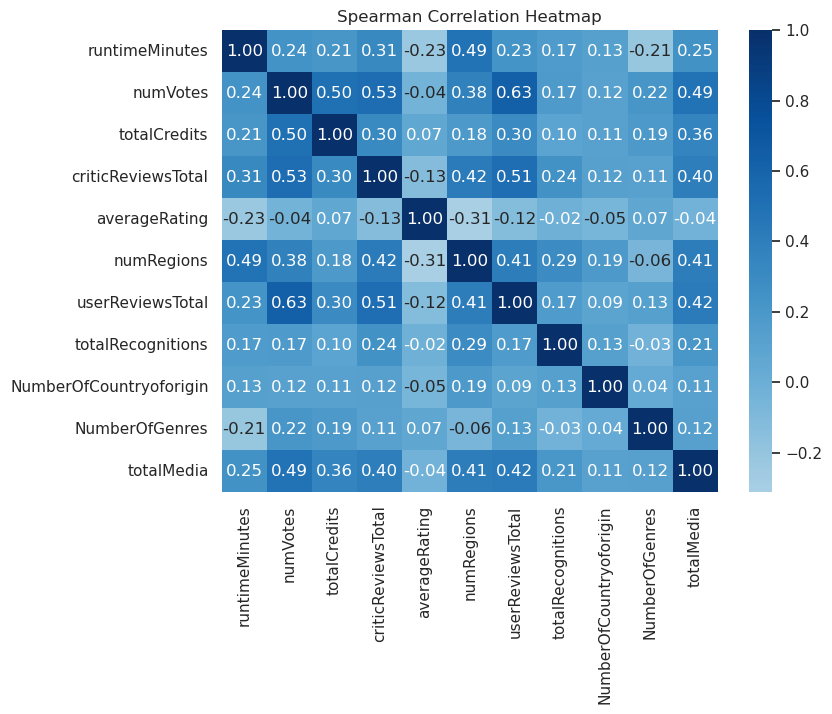

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Calcola la matrice di correlazione di Spearman per le variabili di interesse
corr, _ = spearmanr(train_continuous)

# Crea un DataFrame per la matrice di correlazione
corr_df = pd.DataFrame(corr, index=train_continuous.columns, columns=train_continuous.columns)

# Crea la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap=plt.cm.Blues, center=0, fmt='.2f', cbar=True)

# Aggiungi il titolo
plt.title('Spearman Correlation Heatmap')

# Mostra il grafico
plt.show()


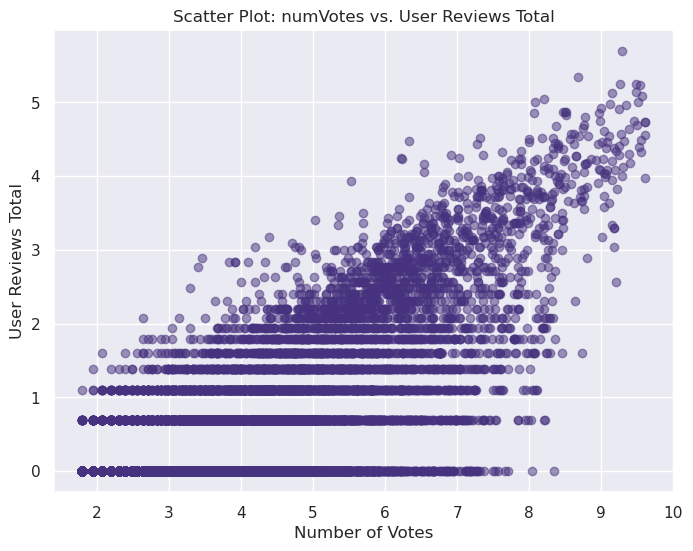

In [11]:
import matplotlib.pyplot as plt

# Supponiamo che tu voglia fare uno scatter plot tra 'runtimeMinutes' e 'numVotes'
plt.figure(figsize=(8, 6))

# Crea il grafico scatter
plt.scatter(data_train['numVotes'], data_train['userReviewsTotal'], alpha=0.5)

# Aggiungi etichette agli assi e titolo
plt.xlabel('Number of Votes')
plt.ylabel('User Reviews Total')
plt.title('Scatter Plot: numVotes vs. User Reviews Total')

# Mostra il grafico
plt.show()


## Univariate Regression

In [12]:
x_train = train_continuous["numVotes"].values.reshape(-1, 1)
y_train = train_continuous["userReviewsTotal"].values

x_test = test_continuous["numVotes"].values.reshape(-1, 1)
y_test = test_continuous["userReviewsTotal"].values

### Linear Regression

Coefficients: 
 [0.4394586]
Intercept: 
 -1.10915898210385


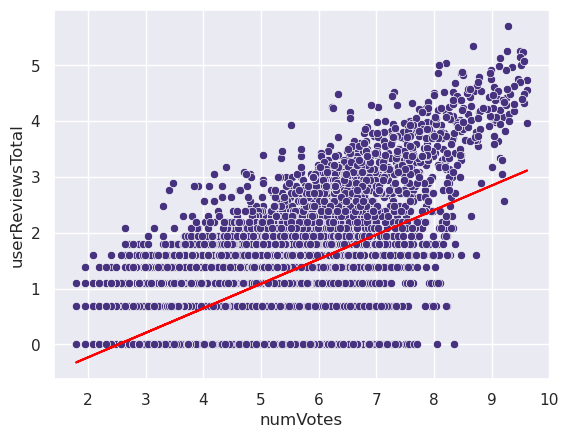

In [13]:
regLinear = LinearRegression()
regLinear.fit(x_train, y_train)

print('Coefficients: \n', regLinear.coef_)
print('Intercept: \n', regLinear.intercept_)

sns.scatterplot(data=train_continuous, x="numVotes", y="userReviewsTotal")
plt.plot(x_train, regLinear.coef_[0]*x_train+regLinear.intercept_, c="red")

In [14]:
y_pred = regLinear.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.539
MSE: 0.399
MAE: 0.474


### Ridge

Coefficients: 
 [0.43944556]
Intercept: 
 -1.1091075410747542


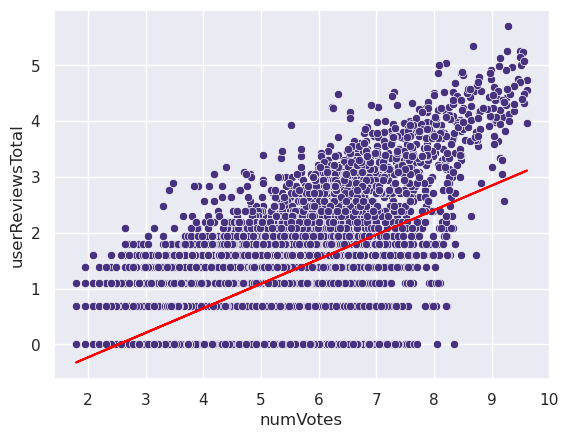

In [15]:
regRidge = Ridge()
regRidge.fit(x_train, y_train)
print('Coefficients: \n', regRidge.coef_)
print('Intercept: \n', regRidge.intercept_)

sns.scatterplot(data=train_continuous, x="numVotes", y="userReviewsTotal")
plt.plot(x_train, regRidge.coef_[0]*x_train+regRidge.intercept_, c="red")

In [16]:
y_pred = regRidge.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.539
MSE: 0.399
MAE: 0.474


### Lasso

Coefficients: 
 [0.43515945]
Intercept: 
 -1.0921959718198049


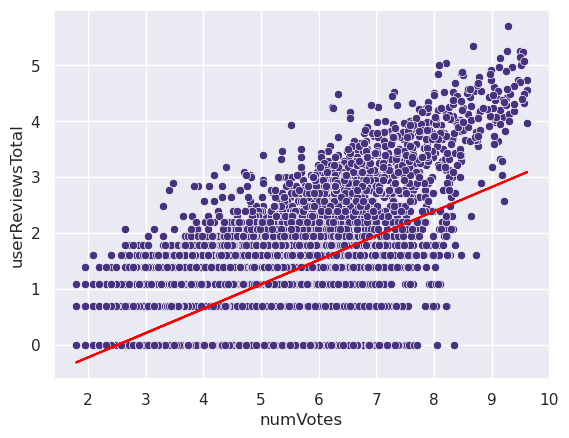

In [17]:
regLasso = Lasso(alpha=0.01) # reduced alpha to reduce penalty
regLasso.fit(x_train, y_train)
print('Coefficients: \n', regLasso.coef_)
print('Intercept: \n', regLasso.intercept_)

sns.scatterplot(data=train_continuous, x="numVotes", y="userReviewsTotal")
plt.plot(x_train, regLasso.coef_[0]*x_train+regLasso.intercept_, c="red")

In [18]:
y_pred = regLasso.predict(x_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.538
MSE: 0.399
MAE: 0.473


### Non Linear Regression

In [19]:
# Decision Tree Regressor

regDT = DecisionTreeRegressor()

# Definizione dei parametri per il GridSearch
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV con 5-fold cross-validation
grid_search = GridSearchCV(estimator=regDT, param_grid=param_grid, cv=5, scoring='r2', verbose=1)
grid_search.fit(x_train, y_train)

# Migliori parametri trovati
print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score (CV):", grid_search.best_score_)

# Addestramento del modello con i migliori parametri
best_regDT = grid_search.best_estimator_
best_regDT.fit(x_train, y_train)

# Predizioni e valutazione
y_pred = best_regDT.predict(x_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best R2 Score (CV): 0.5588241016010973
R2: 0.571
MSE: 0.371
MAE: 0.448


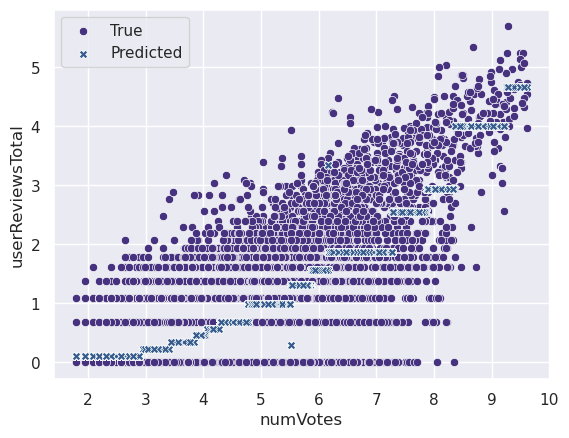

In [20]:
sns.scatterplot(data=train_continuous, x="numVotes", y="userReviewsTotal", label="True")
sns.scatterplot(data=train_continuous, x="numVotes", y=best_regDT.predict(x_train), label="Predicted", marker="X")
plt.legend()
plt.show()

In [21]:
# KNN Regressor
k_values = range(1, 21)
mean_r2_scores = []

# Impostazione della cross-validation a 5 fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Mini cross-validation per trovare il miglior k
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2_scores = []

    # Esegui la cross-validation per ogni fold
    for train_idx, val_idx in kf.split(x_train):
        X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Allena il modello
        knn.fit(X_train_fold, y_train_fold)
        y_val_pred = knn.predict(X_val_fold)
        
        # Calcola il punteggio R2 per il fold corrente
        r2_scores.append(r2_score(y_val_fold, y_val_pred))

    # Calcola la media dei punteggi R2 per ciascun k
    mean_r2_scores.append(np.mean(r2_scores))

# Trova il miglior k
best_k = k_values[np.argmax(mean_r2_scores)]
print(f"Best k: {best_k} with R2: {max(mean_r2_scores):.3f}")

# Allena il modello finale con il miglior k trovato
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(x_train, y_train)

# Predizioni e valutazione sui dati di test
y_pred = best_knn.predict(x_test)
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))



Best k: 20 with R2: 0.552
R2: 0.555
MSE: 0.385
MAE: 0.446


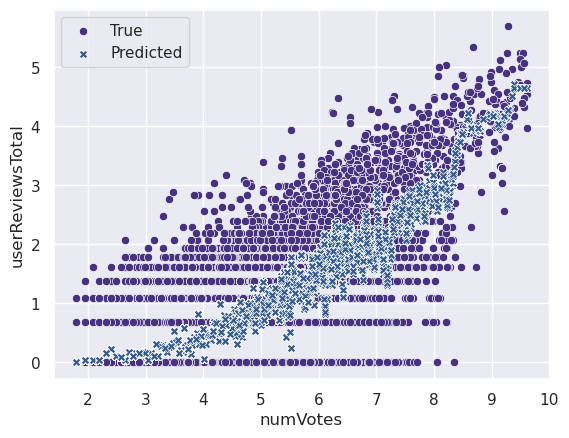

In [22]:
sns.scatterplot(data=train_continuous, x="numVotes", y="userReviewsTotal", label="True")
sns.scatterplot(data=train_continuous, x="numVotes", y=best_knn.predict(x_train), label="Predicted", marker="X")
plt.legend()
plt.show()

## Multiple Regression

In [23]:
X_train = train_continuous[["numVotes", "totalMedia", "criticReviewsTotal"]].values
y_train = train_continuous["userReviewsTotal"].values

X_test = test_continuous[["numVotes", "totalMedia", "criticReviewsTotal"]].values
y_test = test_continuous["userReviewsTotal"].values

# Linear Regression
regLinear = LinearRegression()
regLinear.fit(X_train, y_train)

# Make predictions
y_pred = regLinear.predict(X_test)

In [24]:
print('Coefficients:', regLinear.coef_)
print('Intercept:', regLinear.intercept_)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))


Coefficients: [0.27419755 0.09200147 0.40295695]
Intercept: -0.7323991193564735
R2: 0.620
MSE: 0.329
MAE: 0.426


### Ridge & Lasso

In [25]:
# Create and train the model
regRidge = Ridge()
regRidge.fit(X_train, y_train)

# Make predictions
y_pred = regRidge.predict(X_test)

print('Coefficients:', regRidge.coef_)
print('Intercept:', regRidge.intercept_)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

Coefficients: [0.27420612 0.09201127 0.40289395]
Intercept: -0.7324194228285833
R2: 0.620
MSE: 0.329
MAE: 0.426


In [26]:
# Create and train the model
regLasso = Lasso(alpha=0.01)
regLasso.fit(X_train, y_train)

# Make predictions
y_pred = regLasso.predict(X_test)

print('Coefficients:', regLasso.coef_)
print('Intercept:', regLasso.intercept_)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

Coefficients: [0.27744796 0.08657365 0.38594117]
Intercept: -0.7317128024235243
R2: 0.620
MSE: 0.329
MAE: 0.427


### Non Linear

In [27]:
# Decision Tree Regressor

# GridSearch for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# Best model
best_tree = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Train and evaluate the model
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))



Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
R2: 0.636
MSE: 0.315
MAE: 0.414


In [28]:
# Mini cross-validation to find the best k
k_values = range(1, 21)  # Test k from 1 to 20
mean_r2_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2_scores = []
    
    # Perform cross-validation
    for train_idx, val_idx in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        knn.fit(X_train_fold, y_train_fold)
        y_val_pred = knn.predict(X_val_fold)
        r2_scores.append(r2_score(y_val_fold, y_val_pred))
    
    mean_r2_scores.append(np.mean(r2_scores))

# Find the best k
best_k = k_values[np.argmax(mean_r2_scores)]
print(f"Best k: {best_k} with R2: {max(mean_r2_scores):.3f}")


Best k: 20 with R2: 0.623


In [29]:
# Train the KNN Regressor with the best k
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_best.predict(X_test)

# Evaluate the model on the test set
print('Test R2: %.3f' % r2_score(y_test, y_pred))
print('Test MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('Test MAE: %.3f' % mean_absolute_error(y_test, y_pred))

Test R2: 0.638
Test MSE: 0.313
Test MAE: 0.409


## Multivariate Regression

In [30]:
from sklearn.multioutput import MultiOutputRegressor

X_train = train_continuous[["numVotes", "criticReviewsTotal", "runtimeMinutes"]].values
y_train = train_continuous[["userReviewsTotal", "totalMedia"]].values

X_test = test_continuous[["numVotes", "runtimeMinutes", "criticReviewsTotal"]].values
y_test = test_continuous[["userReviewsTotal", "totalMedia"]].values

# Linear Regression
regLinear = MultiOutputRegressor(LinearRegression())
regLinear.fit(X_train, y_train)

# Make predictions
y_pred = regLinear.predict(X_test)

In [31]:
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))


R2: 0.388
MSE: 0.638
MAE: 0.627


### Multioutput of Ridge and Lasso

In [32]:
# Ridge

regRidge = MultiOutputRegressor(Ridge())
regRidge.fit(X_train, y_train)

# Make predictions
y_pred = regRidge.predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.388
MSE: 0.638
MAE: 0.627


In [33]:
# Lasso

regLasso = MultiOutputRegressor(Lasso(alpha=0.1))
regLasso.fit(X_train, y_train)

# Make predictions
y_pred = regLasso.predict(X_test)

print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.390
MSE: 0.640
MAE: 0.624


### Non Linear Multivariate Regression

In [34]:
# KNN: Cross-validation to find the best k
k_values = range(1, 21)  # Test k from 1 to 20
mean_r2_scores_knn = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

# Loop through k values and evaluate performance
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    r2_scores = []
    
    # Cross-validation for KNN
    for train_idx, val_idx in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        knn.fit(X_train_fold, y_train_fold)
        y_val_pred = knn.predict(X_val_fold)
        r2_scores.append(r2_score(y_val_fold, y_val_pred))
    
    mean_r2_scores_knn.append(np.mean(r2_scores))

# Find the best k based on cross-validation performance
best_k_knn = k_values[np.argmax(mean_r2_scores_knn)]
print(f"Best k for KNN: {best_k_knn} with R2: {max(mean_r2_scores_knn):.3f}")

# Train KNN using the best k found
knn_best = KNeighborsRegressor(n_neighbors=best_k_knn)
knn_multioutput = MultiOutputRegressor(knn_best)
knn_multioutput.fit(X_train, y_train)

# Predictions and evaluation metrics for KNN
y_pred_knn = knn_multioutput.predict(X_test)
print('KNN R2: %.3f' % r2_score(y_test, y_pred_knn))
print('KNN MSE: %.3f' % mean_squared_error(y_test, y_pred_knn))
print('KNN MAE: %.3f' % mean_absolute_error(y_test, y_pred_knn))

Best k for KNN: 20 with R2: 0.476
KNN R2: 0.417
KNN MSE: 0.619
KNN MAE: 0.599


In [35]:
# Decision Tree: GridSearch to find the best hyperparameters
param_grid_tree = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# Initialize Decision Tree regressor
reg_tree = DecisionTreeRegressor()

# Perform GridSearch for Decision Tree hyperparameters
grid_search_tree = GridSearchCV(reg_tree, param_grid_tree, cv=5, scoring='neg_mean_squared_error')
grid_search_tree.fit(X_train, y_train)

# Best parameters found from GridSearch
print(f"Best parameters for Decision Tree: {grid_search_tree.best_params_}")

# Use the best model found by GridSearch
tree_best = grid_search_tree.best_estimator_
tree_multioutput = MultiOutputRegressor(tree_best)
tree_multioutput.fit(X_train, y_train)

# Predictions and evaluation metrics for Decision Tree
y_pred_tree = tree_multioutput.predict(X_test)
print('Decision Tree R2: %.3f' % r2_score(y_test, y_pred_tree))
print('Decision Tree MSE: %.3f' % mean_squared_error(y_test, y_pred_tree))
print('Decision Tree MAE: %.3f' % mean_absolute_error(y_test, y_pred_tree))


Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree R2: 0.432
Decision Tree MSE: 0.604
Decision Tree MAE: 0.571
